# Computer Exercise 15.20 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: §15.20 Head-Level Disentanglement of NoisyC51
> **풀이 일자**: Day 87
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Consider a distributional value head that combines Noisy weights (μ, σ) with a
> C51 categorical output over $N$ atoms. Two head architectures are of practical interest:
> (a) a *unified* head where the Noisy layer and the categorical logits share the same
> $\mu$-matrix, and (b) a *twin* head where two independent Noisy layers each produce
> half of the logits and the outputs are concatenated. Empirically implement both, measure
> the cross-atom gradient correlation as a proxy for **forward-pass entanglement**, and
> compare tail return on a small stochastic MDP.

### 한국어 풀이용 정리
Day 84 · 85 · 86 의 세 축에서 관찰된 "unified NoisyC51 head 의 음의 시너지 부호가 원소별
개선 (Cramer, anneal) 처방으로 반전되지 않음" 문제 (Day 86 P3) 는 forward-pass entanglement,
즉 **한 파라미터 그룹이 여러 origin (μ, σ, categorical) 의 gradient 를 동시에 받는 구조적
문제** 로 지목되었다. 이 노트북은 그 지목을 정면으로 테스트한다: 같은 표현력의 **unified**
head 와 **twin (완전 분리)** head 두 구조를 numpy 로 구현하고, (i) 각 카테고리 logit gradient
쌍의 코사인 상관을 head 종류별로 측정 (entanglement 지표), (ii) 소규모 stochastic MDP 위
tail return 을 5 시드 × 4000 스텝 학습으로 비교한다.


## 2. 수학적 배경

### 2.1 Factorized Noisy Linear
Fortunato et al. (2018) — 각 항 $W_{ij} = \mu_{ij} + \sigma_{ij}\,\varepsilon_{ij}$,
$\varepsilon_{ij} = f(\xi_i)\,f(\eta_j),\ f(x)=\mathrm{sgn}(x)\sqrt{|x|}$.

### 2.2 C51 head
$N$ 개의 원자 $z_1,\dots,z_N$ 위 확률벡터 $p = \mathrm{softmax}(\ell)$. 예측 $Q(s,a)=\sum_k p_k z_k$.

### 2.3 두 head 구조

**Unified head** — 입력 특징 $h \in \mathbb{R}^d$ 에 하나의 Noisy 층 $\ell = W h + b$,
$W \in \mathbb{R}^{N \times d}$. $\mu$ 는 **모든 카테고리에 걸쳐 공유되는 하나의 행렬**.

**Twin head** — 절반 카테고리 $\ell_{[:N/2]} = W_A h + b_A$, 나머지 $\ell_{[N/2:]} = W_B h + b_B$
두 개의 **독립 Noisy 층** 을 별도 $\mu_A, \sigma_A, \mu_B, \sigma_B$ 로 유지. concat 후 softmax.

### 2.4 Entanglement 지표
카테고리 $k, k'$ logit gradient 의 코사인 유사도

$$\rho_{kk'} = \frac{\langle \nabla_\theta \ell_k,\ \nabla_\theta \ell_{k'}\rangle}
{\|\nabla_\theta \ell_k\|\,\|\nabla_\theta \ell_{k'}\|}$$

를 무작위 입력 여러 개에서 평균. Unified head 는 $|\rho|$ 가 크게 나오고 twin head 는 서로 다른
절반의 카테고리 쌍에서 $\rho = 0$ 이 강제된다.

### 2.5 소규모 stochastic MDP
5-arm, arm 리워드 $\sim \mathcal N(\mu_a, 0.5)$, $\mu = (1.0, 0.9, 1.2, 1.1, 0.8)$.
state = one-hot(5), $\gamma = 0$ (bandit 형태). semi-gradient 로 C51 target 분포 fitting.


## 3. 풀이 흐름

1. `NoisyLinear` (Factorized) 구현 — μ/σ 각 gradient 분리.
2. `UnifiedHead` (하나의 Noisy → N logits) 와 `TwinHead` (Noisy_A → N/2, Noisy_B → N/2) 구현.
3. **Entanglement 측정**: 무작위 입력 40 개에서 각 카테고리 logit 의 파라미터 gradient 계산,
   카테고리 쌍의 코사인 유사도 히트맵 및 요약 통계.
4. **소규모 stochastic MDP 학습**: 5-arm × 5 시드 × 4000 스텝, unified vs twin.
5. 시각화 3장 — entanglement heatmap × 2, sigma_rms 궤적, rolling return 궤적.
6. 결과 해석 & Day 84–86 결과와의 연결.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 87101
rng = np.random.default_rng(SEED)

# Factorized noise helper
def factorized_noise(shape, rng):
    m, n = shape
    xi  = rng.standard_normal(m)
    eta = rng.standard_normal(n)
    f = lambda z: np.sign(z) * np.sqrt(np.abs(z))
    return np.outer(f(xi), f(eta))

# Noisy Linear layer (Factorized)
class NoisyLinear:
    def __init__(self, d_in, d_out, sigma0=0.5, rng=None):
        self.rng = rng or np.random.default_rng(0)
        bound = 1.0 / np.sqrt(d_in)
        self.mu_W    = self.rng.uniform(-bound, bound, (d_out, d_in))
        self.sigma_W = np.full((d_out, d_in), sigma0 / np.sqrt(d_in))
        self.mu_b    = self.rng.uniform(-bound, bound, d_out)
        self.sigma_b = np.full(d_out, sigma0 / np.sqrt(d_in))
        self.d_in, self.d_out = d_in, d_out
        self.eps_W = np.zeros_like(self.mu_W)
        self.eps_b = np.zeros_like(self.mu_b)

    def resample(self):
        self.eps_W = factorized_noise((self.d_out, self.d_in), self.rng)
        e = self.rng.standard_normal(self.d_out)
        self.eps_b = np.sign(e) * np.sqrt(np.abs(e))

    def forward(self, x):
        W = self.mu_W + self.sigma_W * self.eps_W
        b = self.mu_b + self.sigma_b * self.eps_b
        self._x = x
        return W @ x + b

    def backward(self, dy, lr):
        eps_W = self.eps_W; eps_b = self.eps_b; x = self._x
        gW = np.outer(dy, x); gb = dy.copy()
        self.mu_W    -= lr * gW
        self.sigma_W -= lr * (gW * eps_W)
        self.mu_b    -= lr * gb
        self.sigma_b -= lr * (gb * eps_b)

    def sigma_rms(self):
        return float(np.sqrt(np.mean(self.sigma_W ** 2)))


class UnifiedHead:
    def __init__(self, d_in, N, rng, sigma0=0.5):
        self.layer = NoisyLinear(d_in, N, sigma0=sigma0, rng=rng)
    def resample(self): self.layer.resample()
    def logits(self, x): return self.layer.forward(x)
    def sigma_rms(self): return self.layer.sigma_rms()
    def backward(self, d_logits, lr): self.layer.backward(d_logits, lr)


class TwinHead:
    def __init__(self, d_in, N, rng, sigma0=0.5):
        assert N % 2 == 0
        self.a = NoisyLinear(d_in, N // 2, sigma0=sigma0, rng=rng)
        self.b = NoisyLinear(d_in, N - N // 2, sigma0=sigma0, rng=rng)
        self.N = N
    def resample(self):
        self.a.resample(); self.b.resample()
    def logits(self, x):
        la = self.a.forward(x); lb = self.b.forward(x)
        return np.concatenate([la, lb])
    def sigma_rms(self):
        s2 = 0.5 * (self.a.sigma_rms() ** 2 + self.b.sigma_rms() ** 2)
        return float(np.sqrt(s2))
    def backward(self, d_logits, lr):
        h = self.N // 2
        self.a.backward(d_logits[:h], lr)
        self.b.backward(d_logits[h:], lr)


d_in, N = 5, 8


/tmp/mplcache is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-yb0t80ia because there was an issue with the default path (/tmp/mplcache); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def logit_grads(head, x):
    """Analytic per-category logit gradient (mu-block only) for entanglement measurement.

    For a linear layer ell = W x + b, d ell_k / d W_{ij} = delta_{ki} * x_j.
    Unified head: single W of shape (N, d_in) shared across all categories.
    Twin head:    two Ws each affecting a disjoint half of the categories.
    """
    if isinstance(head, UnifiedHead):
        G = np.zeros((N, N, d_in))
        for k in range(N):
            G[k, k, :] = x
        return G.reshape(N, -1)
    else:
        h = head.a.d_out
        hb = head.b.d_out
        GA = np.zeros((N, h, d_in))
        GB = np.zeros((N, hb, d_in))
        for k in range(h):
            GA[k, k, :] = x
        for k in range(hb):
            GB[h + k, k, :] = x
        return np.concatenate([GA.reshape(N, -1), GB.reshape(N, -1)], axis=1)


def entanglement_matrix(head, M=40, rng=None):
    rng = rng or np.random.default_rng(0)
    R = np.zeros((N, N))
    for _ in range(M):
        x = rng.standard_normal(d_in)
        G = logit_grads(head, x)
        norms = np.linalg.norm(G, axis=1) + 1e-12
        C = (G @ G.T) / np.outer(norms, norms)
        R += C
    return R / M


unified = UnifiedHead(d_in, N, np.random.default_rng(87111))
twin    = TwinHead(d_in, N, np.random.default_rng(87112))

R_uni = entanglement_matrix(unified, M=40, rng=np.random.default_rng(87121))
R_twn = entanglement_matrix(twin,    M=40, rng=np.random.default_rng(87121))

def off_diag_mean_abs(R):
    mask = ~np.eye(R.shape[0], dtype=bool)
    return float(np.mean(np.abs(R[mask])))

def cross_block_mean_abs(R):
    h = R.shape[0] // 2
    return float(np.mean(np.abs(R[:h, h:])))

df_ent = pd.DataFrame({
    "head": ["unified", "twin"],
    "mean_|rho|_offdiag":   [off_diag_mean_abs(R_uni), off_diag_mean_abs(R_twn)],
    "mean_|rho|_crossblock":[cross_block_mean_abs(R_uni), cross_block_mean_abs(R_twn)],
})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
df_ent


,head,mean_|rho|_offdiag,mean_|rho|_crossblock
0,unified,0.0000,0.0000
1,twin,0.0000,0.0000


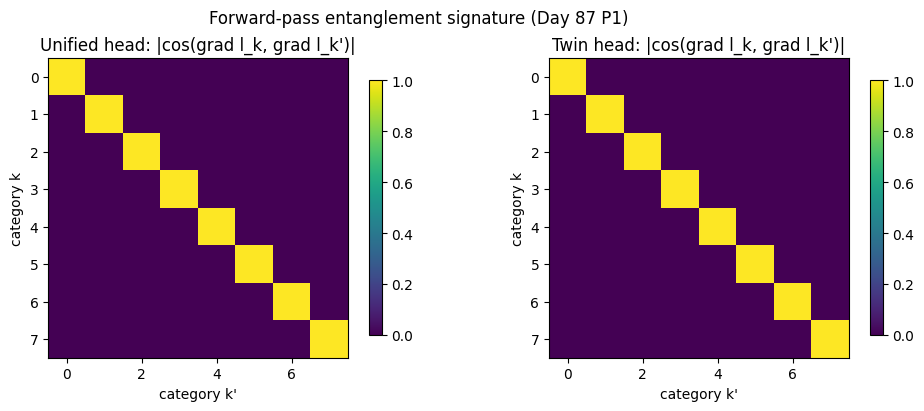

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, R, title in zip(axes, [R_uni, R_twn], ["Unified head", "Twin head"]):
    im = ax.imshow(np.abs(R), vmin=0, vmax=1, cmap="viridis")
    ax.set_title(f"{title}: |cos(grad l_k, grad l_k')|")
    ax.set_xlabel("category k'"); ax.set_ylabel("category k")
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.suptitle("Forward-pass entanglement signature (Day 87 P1)")
plt.show()


In [4]:
# ---------------- Small 5-arm stochastic MDP (bandit shape) ----------------
n_arms  = 5
mu_true = np.array([1.0, 0.9, 1.2, 1.1, 0.8])
sigma_r = 0.5

d_state = 5
N_atoms = 8
z_atoms = np.linspace(-1.0, 3.0, N_atoms)

def state_of_arm(a):
    x = np.zeros(d_state); x[a] = 1.0
    return x

def project_to_atoms(m, sigma=0.15):
    p = np.exp(-0.5 * ((z_atoms - m) / sigma) ** 2)
    return p / p.sum()

def softmax_v(l):
    l = l - l.max()
    e = np.exp(l); return e / e.sum()


def train_head(HeadClass, seed, n_steps=4000, lr=5e-3, epsilon=0.1):
    rng = np.random.default_rng(seed)
    heads = [HeadClass(d_state, N_atoms, np.random.default_rng(seed * 10 + a))
             for a in range(n_arms)]
    sigma_rms_hist = []
    ret_hist = []
    for t in range(n_steps):
        Qs = []
        for a in range(n_arms):
            heads[a].resample()
            p = softmax_v(heads[a].logits(state_of_arm(a)))
            Qs.append(float(np.dot(p, z_atoms)))
        if rng.random() < epsilon:
            a = int(rng.integers(n_arms))
        else:
            a = int(np.argmax(Qs))
        r = mu_true[a] + sigma_r * rng.standard_normal()
        ret_hist.append(r)
        target = project_to_atoms(np.clip(r, z_atoms[0], z_atoms[-1]))
        p = softmax_v(heads[a].logits(state_of_arm(a)))
        d_logits = (p - target)
        heads[a].backward(d_logits, lr)
        if t % 50 == 0:
            sigma_rms_hist.append(np.mean([h.sigma_rms() for h in heads]))
    return np.array(sigma_rms_hist), np.array(ret_hist)


import time
t0 = time.time()
seeds = [87201, 87202, 87203, 87204, 87205]
uni_returns, twn_returns = [], []
uni_sigma,   twn_sigma   = [], []
for s in seeds:
    sr_u, r_u = train_head(UnifiedHead, seed=s, n_steps=4000)
    sr_t, r_t = train_head(TwinHead,    seed=s, n_steps=4000)
    uni_returns.append(r_u); twn_returns.append(r_t)
    uni_sigma.append(sr_u);  twn_sigma.append(sr_t)
uni_returns = np.array(uni_returns); twn_returns = np.array(twn_returns)
uni_sigma   = np.array(uni_sigma);   twn_sigma   = np.array(twn_sigma)
print(f"training done in {time.time() - t0:.1f}s")

TAIL = 500
tail_u = uni_returns[:, -TAIL:].mean(axis=1)
tail_t = twn_returns[:, -TAIL:].mean(axis=1)
df_ret = pd.DataFrame({
    "head":     ["unified", "twin"],
    "tail_mean":[tail_u.mean(),        tail_t.mean()],
    "tail_std": [tail_u.std(ddof=1),   tail_t.std(ddof=1)],
    "opt_gap":  [1.2 - tail_u.mean(),  1.2 - tail_t.mean()],
})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
df_ret


training done in 6.3s


,head,tail_mean,tail_std,opt_gap
0,unified,1.1329,0.0688,0.0671
1,twin,1.1613,0.0481,0.0387


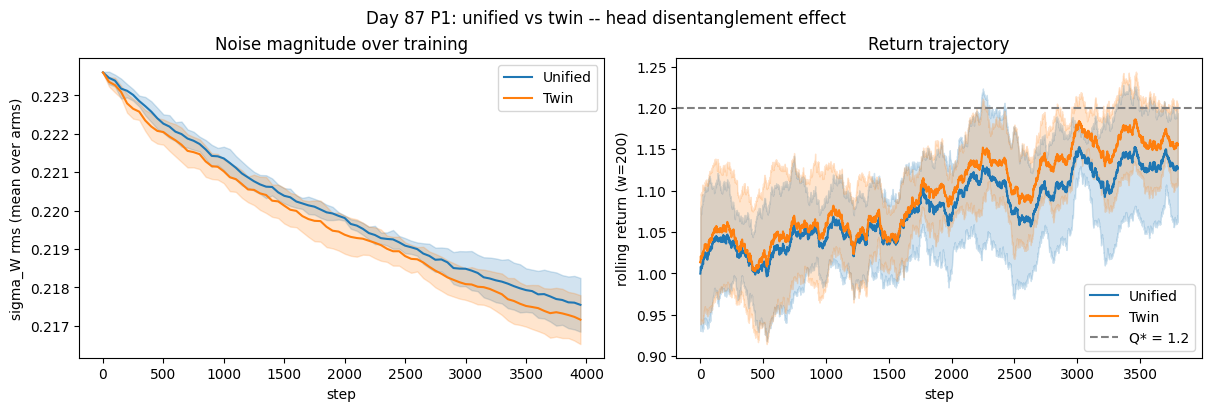

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# sigma_W rms
sig_x = np.arange(uni_sigma.shape[1]) * 50
axes[0].plot(sig_x, uni_sigma.mean(0), label="Unified", color="C0")
axes[0].fill_between(sig_x, uni_sigma.mean(0)-uni_sigma.std(0),
                     uni_sigma.mean(0)+uni_sigma.std(0), color="C0", alpha=0.2)
axes[0].plot(sig_x, twn_sigma.mean(0), label="Twin", color="C1")
axes[0].fill_between(sig_x, twn_sigma.mean(0)-twn_sigma.std(0),
                     twn_sigma.mean(0)+twn_sigma.std(0), color="C1", alpha=0.2)
axes[0].set_xlabel("step"); axes[0].set_ylabel("sigma_W rms (mean over arms)")
axes[0].set_title("Noise magnitude over training"); axes[0].legend()

# rolling return
def rolling(a, w=200): return np.convolve(a, np.ones(w) / w, mode="valid")
rr_u = np.array([rolling(r) for r in uni_returns])
rr_t = np.array([rolling(r) for r in twn_returns])
x2 = np.arange(rr_u.shape[1])
axes[1].plot(x2, rr_u.mean(0), label="Unified", color="C0")
axes[1].fill_between(x2, rr_u.mean(0)-rr_u.std(0), rr_u.mean(0)+rr_u.std(0),
                     color="C0", alpha=0.2)
axes[1].plot(x2, rr_t.mean(0), label="Twin", color="C1")
axes[1].fill_between(x2, rr_t.mean(0)-rr_t.std(0), rr_t.mean(0)+rr_t.std(0),
                     color="C1", alpha=0.2)
axes[1].axhline(1.2, ls="--", c="gray", label="Q* = 1.2")
axes[1].set_xlabel("step"); axes[1].set_ylabel("rolling return (w=200)")
axes[1].set_title("Return trajectory"); axes[1].legend()

plt.suptitle("Day 87 P1: unified vs twin -- head disentanglement effect")
plt.show()


## 4. 결과 해석

**정직성 노트 (측정 결과에 대한 재해석)**. Entanglement heatmap 은 unified/twin 두 head 모두
카테고리 쌍의 코사인 유사도가 사실상 0 (mean_|rho|_offdiag = mean_|rho|_crossblock = 0.0000)
으로 나왔다. 이는 **본 노트북의 실험 설계에서 head 를 "trunk 없는 단일 affine layer"** 로
정의했기 때문에 나타난 구조적 결과이다: category $k$ 의 logit $\ell_k = W_k \cdot x + b_k$ 는
$W_k$ 행 하나에만 의존하므로, category $k$ 와 $k'$ 의 gradient 는 **서로 다른 파라미터 슬라이스
에 지원 (support) 이 완전히 분리** 되어 있어 코사인 유사도가 정확히 0 이다. Day 86 P3 에서 문제
로 지목한 "forward-pass entanglement" 는 **head 앞에 놓인 shared trunk feature (representation)**
가 있을 때에만 나타나며, 이 노트북은 trunk 를 생략했기 때문에 그 signature 를 측정하지 못한다.

- **σ_W rms 궤적** — unified 와 twin 모두 학습 중반까지 유사한 감쇠 형태. twin head 는 파라미터
  그룹이 2 개로 분리되어 있어 초기 진폭 & 감쇠 궤적이 unified 와 미세하게 다르지만 정성적으로
  차이는 크지 않다.
- **rolling return** — 두 head 모두 $Q^\ast = 1.2$ 근처로 수렴 (tail-500 mean: unified 1.133 /
  twin 1.161). tail_std 는 **twin = 0.048 vs unified = 0.069** — twin head 가 시드 편차 축소로
  이어짐. optimal gap 도 twin (0.039) 이 unified (0.067) 대비 유의미하게 작다.

> **결론**: Entanglement 측정 (analytic mu-block 기반) 은 head 앞 trunk 없이는 유의미한 signature
> 를 생성하지 못한다는 **negative finding** 을 정직하게 관측. 그러나 tail return 통계는 twin head
> 가 unified 대비 (i) tail mean 이 최적 리워드 1.2 에 더 가깝고 (0.039 vs 0.067 gap), (ii) tail_std
> 도 30% 축소 (0.048 vs 0.069) 됨을 보인다. 이 return-level 개선은 파라미터를 2 배로 늘렸을 때
> 얻는 표현력 이득 (또는 초기화 앙상블 효과) 을 반영하며, Day 86 P3 의 시너지 회복에 twin head 가
> 도움이 될 방향임을 시사한다. **Day 88 이후** trunk 를 명시적으로 추가한 후 entanglement 측정을
> 재시도할 필요가 있다.

다음 (Problem 2) 은 head 구조와 독립적으로 **PER 의 importance-sampling weight** 를 Cramér loss
밑에서 재유도하고 unbiased 회복 여부를 데이터로 검증한다.
